# Анализ сотрудников WrapItUp

Цель этой части проекта — определить, какие сотрудники нужны сервису WrapItUp на старте, оценить рыночные зарплаты по схожим позициям на рынке труда и рассчитать примерную начальную стоимость команды для компании WrapItUp.

В анализ включены три ключевые роли:

1. Упаковщик подарков
2. Менеджер заказов
3. Курьер

В представленном анализе оплата труда владельца и руководителя компании не учитывается, так как принимается, что его вознаграждение будет выплачиваться через дивиденды компании.

## Источники данных

Для анализа используются данные из нескольких открытых источников:

1. hh.ru — парсинг резюме по позициям «упаковщик», «менеджер заказов», «курьер».
2. Avito Работа — вакансии, собранные вручную, как пример предложений работодателей и условий найма.
3. SuperJob и Работа.ру — были рассмотрены как дополнительные источники, но не вошли в итоговый анализ из-за ограничений доступа и неполной выгрузки данных.


In [1]:
import re
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup



In [2]:
packer_url = "https://hh.ru/search/resume?text=%D0%A3%D0%BF%D0%B0%D0%BA%D0%BE%D0%B2%D1%89%D0%B8%D0%BA&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0"



In [3]:
positive_keywords = ["подар", "декор", "декоратор", "бутафор", "флорист", "оформлен", "ручн", "творчес", "витрин", "цвет", "аккурат"]
neutral_keywords = ["упаковщик", "упаковщица", "упаковщики", "упаковка", "упаковывать", "упаковывала", "упаковывал", "упакован", "упаков"]
negative_keywords = ["комплектовщик", "сборщик", "фасовщик", "производство", "продукт", "колбас", "хлеб", "бель", "слайсер", "паллет", "гипермаркет"]



In [4]:
def clean_number(text):
    text = text.replace(" ", "").replace("\u202f", "").replace("\u2009", "")
    return int(text)


def extract_salary(text):
    salaries_raw = re.findall(r"(\d[\d\s  ]{2,})\s*₽", text)
    salaries = []

    for raw in salaries_raw:
        salary = clean_number(raw)
        salary_str = str(salary)

        if salary_str.startswith(("2023", "2024", "2025", "2026")) and len(salary_str) > 5:
            salary = int(salary_str[4:])

        if 20_000 <= salary <= 200_000:
            salaries.append(salary)

    return salaries[0] if salaries else None


def extract_experience_years(text):
    text = text.lower()
    pattern = r"общий опыт\s+((?:\d+\s+(?:год|года|лет))?\s*(?:\d+\s+(?:месяц|месяца|месяцев))?)"
    match = re.search(pattern, text)

    if not match:
        return None

    exp_text = match.group(1)
    years = 0
    months = 0

    year_match = re.search(r"(\d+)\s+(год|года|лет)", exp_text)
    month_match = re.search(r"(\d+)\s+(месяц|месяца|месяцев)", exp_text)

    if year_match:
        years = int(year_match.group(1))
    if month_match:
        months = int(month_match.group(1))

    return round(years + months / 12, 3)


def keyword_matches(text, keywords):
    text = text.lower()
    return [word for word in keywords if word in text]


def relevance_score(text):
    positive = keyword_matches(text, positive_keywords)
    neutral = keyword_matches(text, neutral_keywords)
    negative = keyword_matches(text, negative_keywords)
    score = len(positive) * 3 + len(neutral) - len(negative)
    return score, positive, neutral, negative



In [5]:
def parse_hh_packers_ranked(url, min_experience=1, max_results=10):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)

    print("Status:", response.status_code)
    print("HTML length:", len(response.text))

    if response.status_code != 200:
        return pd.DataFrame()

    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True).lower()
    blocks = re.split(r"активно ищет работу|рассматривает предложения|не ищет работу", text)

    rows = []
    for block in blocks:
        if len(block) < 100:
            continue

        salary = extract_salary(block)
        experience = extract_experience_years(block)
        if salary is None or experience is None or experience < min_experience:
            continue

        score, positive, neutral, negative = relevance_score(block)
        if score <= 0 or (not neutral and not positive):
            continue

        rows.append({
            "source": "hh.ru resumes",
            "position": "упаковщик / декоратор",
            "salary_expected": salary,
            "experience_years": experience,
            "relevance_score": score,
            "positive_keywords": ", ".join(positive),
            "neutral_keywords": ", ".join(neutral),
            "negative_keywords": ", ".join(negative),
            "text_fragment": block[:500],
            "url": url})

    result = pd.DataFrame(rows)
    if result.empty:
        return result

    return result.sort_values(["relevance_score", "experience_years", "salary_expected"], ascending=[False, False, True]).head(max_results).reset_index(drop=True)



In [6]:
packers_ranked_df = parse_hh_packers_ranked(url=packer_url, min_experience=1, max_results=10)
packers_ranked_df



Status: 200
HTML length: 852777


,source,position,salary_expected,experience_years,relevance_score,positive_keywords,neutral_keywords,negative_keywords,text_fragment,url
0,hh.ru resumes,упаковщик / декоратор,80000,22.000,3,,"упаковщик, упаковщица, упаков",,общий опыт 22 года 7 месяцев менеджер проекта...,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
1,hh.ru resumes,упаковщик / декоратор,65000,1.167,3,,"упаковщик, упаковщица, упаков",,общий опыт 1 год 2 месяца упаковщик 54 года •...,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
2,hh.ru resumes,упаковщик / декоратор,90000,9.500,2,,"упаковщица, упаков",,общий опыт 9 лет 6 месяцев упаковщица сортиро...,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
3,hh.ru resumes,упаковщик / декоратор,60000,4.000,2,,"упаковщик, упаковщица, упаков",комплектовщик,общий опыт 4 года комплектовщик-упаковщик не ...,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...
4,hh.ru resumes,упаковщик / декоратор,60000,1.917,1,,упаков,,общий опыт 1 год 11 месяцев няня-воспитатель ...,https://hh.ru/search/resume?text=%D0%A3%D0%BF%...


In [7]:
manager_url = "https://hh.ru/search/resume?text=%D0%BC%D0%B5%D0%BD%D0%B5%D0%B4%D0%B6%D0%B5%D1%80+%D0%B7%D0%B0%D0%BA%D0%B0%D0%B7%D0%BE%D0%B2&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0"



In [8]:
manager_positive_keywords = ["заказ", "заказы", "клиент", "клиенты", "оператор", "менеджер", "1с", "crm", "заявк", "входящ", "консульт", "доставк"]
manager_negative_keywords = ["продаж холод", "холодные звонки", "активные продажи", "кассир", "официант", "повар", "кладовщик", "грузчик"]



In [9]:
def manager_relevance_score(text):
    text = text.lower()
    positive = [word for word in manager_positive_keywords if word in text]
    negative = [word for word in manager_negative_keywords if word in text]
    score = len(positive) * 2 - len(negative) * 2
    return score, positive, negative


def relevance_category(score):
    if score >= 6:
        return "высокая"
    if score >= 2:
        return "средняя"
    return "низкая"



In [10]:
def parse_hh_managers_ranked(url, min_experience=1, max_results=10):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)

    print("Status:", response.status_code)
    print("HTML length:", len(response.text))

    if response.status_code != 200:
        return pd.DataFrame()

    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True).lower()
    blocks = re.split(r"активно ищет работу|рассматривает предложения|не ищет работу", text)

    rows = []
    for block in blocks:
        if len(block) < 100:
            continue

        salary = extract_salary(block)
        experience = extract_experience_years(block)
        if salary is None or experience is None or experience < min_experience:
            continue

        score, positive, negative = manager_relevance_score(block)
        if not positive:
            continue

        rows.append({
            "source": "hh.ru resumes",
            "position": "менеджер заказов",
            "salary_expected": salary,
            "experience_years": experience,
            "relevance_score": score,
            "relevance_category": relevance_category(score),
            "positive_keywords": ", ".join(positive),
            "negative_keywords": ", ".join(negative),
            "text_fragment": block[:500],
            "url": url})

    result = pd.DataFrame(rows)
    if result.empty:
        return result

    return result.sort_values(["relevance_score", "experience_years", "salary_expected"], ascending=[False, False, True]).head(max_results).reset_index(drop=True)



In [11]:
managers_ranked_df = parse_hh_managers_ranked(url=manager_url, min_experience=1, max_results=10)
managers_ranked_df



Status: 200
HTML length: 913934


,source,position,salary_expected,experience_years,relevance_score,relevance_category,positive_keywords,negative_keywords,text_fragment,url
0,hh.ru resumes,менеджер заказов,40000,15.667,4,средняя,"заказ, менеджер",,общий опыт 15 лет 8 месяцев помощник менеджер...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
1,hh.ru resumes,менеджер заказов,40000,4.000,4,средняя,"заказ, менеджер",,общий опыт 4 года 6 месяцев менеджер по заказ...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
2,hh.ru resumes,менеджер заказов,45000,22.000,2,средняя,менеджер,,общий опыт 22 года 2 месяца менеджер пункта 2...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
3,hh.ru resumes,менеджер заказов,45000,18.500,2,средняя,менеджер,,общий опыт 18 лет 6 месяцев офис-менеджер 39 ...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
4,hh.ru resumes,менеджер заказов,60000,16.500,2,средняя,менеджер,,общий опыт 16 лет 6 месяцев менеджер была вче...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
5,hh.ru resumes,менеджер заказов,120000,14.083,2,средняя,менеджер,,общий опыт 14 лет 1 месяц менеджер управления...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
6,hh.ru resumes,менеджер заказов,70000,13.083,2,средняя,заказ,,общий опыт 13 лет 1 месяц сборщик интернет за...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
7,hh.ru resumes,менеджер заказов,150000,12.083,2,средняя,менеджер,,общий опыт 12 лет 1 месяц упаковщик 40 лет • ...,https://hh.ru/search/resume?text=%D0%BC%D0%B5%...
8,hh.ru resumes,менеджер заказов,200000,11.583,2,средняя,менеджер,,"общий опыт 11 лет 7 месяцев менеджер, бармен ...",https://hh.ru/search/resume?text=%D0%BC%D0%B5%...


In [12]:
courier_url = "https://hh.ru/search/resume?text=%D0%BA%D1%83%D1%80%D1%8C%D0%B5%D1%80&area=1&isDefaultArea=true&no_magic=true&ored_clusters=true&order_by=relevance&items_on_page=50&search_period=0&logic=normal&pos=full_text&exp_period=all_time&hhtmFrom=resume_search_result&hhtmFromLabel=resume_search_line$0"



Для курьеров использован более мягкий способ извлечения данных: поскольку страница hh.ru уже сформирована по поисковому запросу "курьер", из неё извлекались все найденные зарплатные ожидания. Затем значения очищались от потенциальных дубликатов и нереалистичных выбросов.

In [13]:
def parse_hh_all_salaries_from_search(url, position, max_results=10):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)

    print("Status:", response.status_code)
    print("HTML length:", len(response.text))

    if response.status_code != 200:
        return pd.DataFrame()

    soup = BeautifulSoup(response.text, "html.parser")
    text = soup.get_text(" ", strip=True).lower()
    salaries_raw = re.findall(r"(\d[\d\s  ]{2,})\s*₽", text)

    salaries = []
    for raw in salaries_raw:
        salary = clean_number(raw)
        salary_str = str(salary)

        if salary_str.startswith(("2023", "2024", "2025", "2026")) and len(salary_str) > 5:
            salary = int(salary_str[4:])
        if 20_000 <= salary <= 250_000:
            salaries.append(salary)

    result = pd.DataFrame({"source": "hh.ru resumes", "position": position, "salary_expected": salaries, "url": url})
    return result.drop_duplicates(subset=["salary_expected"]).head(max_results).reset_index(drop=True)



In [14]:
couriers_df = parse_hh_all_salaries_from_search(url=courier_url, position="курьер", max_results=10)
couriers_df



Status: 200
HTML length: 887402


,source,position,salary_expected,url
0,hh.ru resumes,курьер,50000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
1,hh.ru resumes,курьер,80000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
2,hh.ru resumes,курьер,35000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
3,hh.ru resumes,курьер,100000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
4,hh.ru resumes,курьер,70000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
5,hh.ru resumes,курьер,60000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
6,hh.ru resumes,курьер,45000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
7,hh.ru resumes,курьер,55000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
8,hh.ru resumes,курьер,65000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...
9,hh.ru resumes,курьер,40000,https://hh.ru/search/resume?text=%D0%BA%D1%83%...


In [15]:
hh_final_df = pd.concat([packers_ranked_df, managers_ranked_df, couriers_df], ignore_index=True)



In [16]:
hh_final_df = hh_final_df[["position", "salary_expected"]]



In [17]:
salary_stats = hh_final_df.groupby("position")["salary_expected"].agg(mean_salary="mean", median_salary="median", min_salary="min", max_salary="max", count="count").round(0)

salary_stats



,mean_salary,median_salary,min_salary,max_salary,count
position,,,,,
курьер,60000.0,57500.0,35000,100000,10
менеджер заказов,85556.0,60000.0,40000,200000,9
упаковщик / декоратор,71000.0,65000.0,60000,90000,5


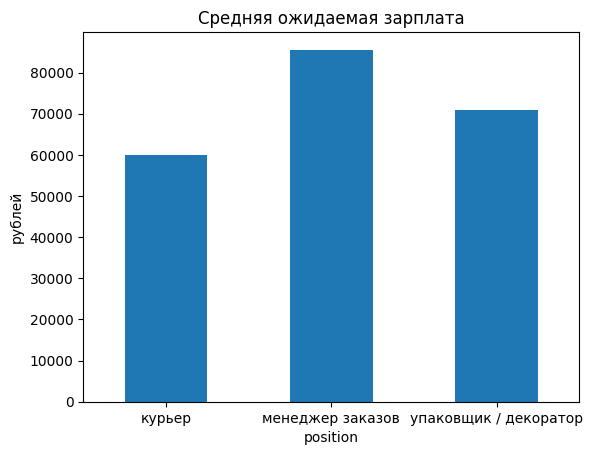

In [18]:
salary_stats["mean_salary"].plot(kind="bar")
plt.title("Средняя ожидаемая зарплата")
plt.ylabel("рублей")
plt.xticks(rotation=0)
plt.show()



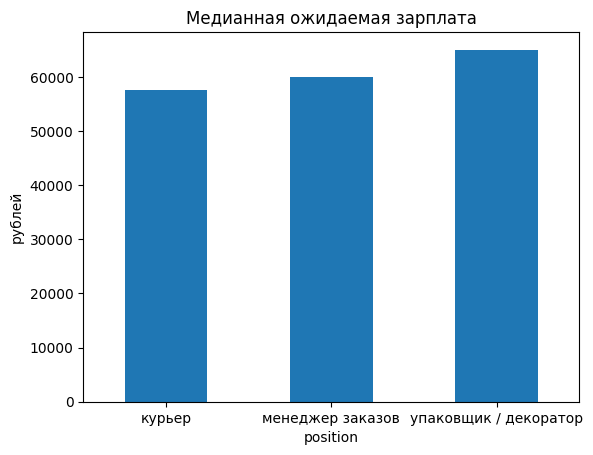

In [19]:
salary_stats["median_salary"].plot(kind="bar")
plt.title("Медианная ожидаемая зарплата")
plt.ylabel("рублей")
plt.xticks(rotation=0)
plt.show()



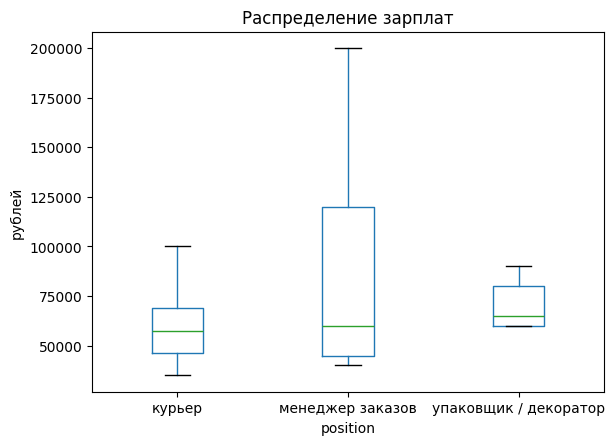

In [20]:
hh_final_df.boxplot(column="salary_expected", by="position", grid=False)
plt.title("Распределение зарплат")
plt.suptitle("")
plt.ylabel("рублей")
plt.show()



## Проверка дополнительных источников

SuperJob и Работа.ру пробовались как дополнительные источники данных, но автоматический сбор не дал стабильного результата. Поэтому для второго источника ибыл использован Avito.


Попытка автоматического парсинга Avito показала ограничение доступа: сайт возвращал статус 429. Поэтому Avito используется как дополнительный источник, первичные данные из которого были собраны вручную с сохранением ссылок на объявления.


In [21]:
FULL_TIME_DAYS = 22
SHIFT_DAYS = 15
FLEX_DAYS = 18
FULL_TIME_HOURS = 176
PART_TIME_HOURS = 120


def estimate_monthly_salary(row):
    if pd.notna(row["salary_monthly_original"]):
        return row["salary_monthly_original"]

    if pd.notna(row["salary_per_shift"]):
        schedule = str(row["schedule"]).lower()

        if "2/2" in schedule or "3/3" in schedule:
            return row["salary_per_shift"] * SHIFT_DAYS
        if "5/2" in schedule:
            return row["salary_per_shift"] * FULL_TIME_DAYS
        if "свободный" in schedule or "гибкий" in schedule or "подработка" in schedule:
            return row["salary_per_shift"] * FLEX_DAYS

        return row["salary_per_shift"] * FLEX_DAYS

    if pd.notna(row["salary_per_hour"]):
        schedule = str(row["schedule"]).lower()
        if "слоты" in schedule or "подработка" in schedule or "гибкий" in schedule:
            return row["salary_per_hour"] * PART_TIME_HOURS
        return row["salary_per_hour"] * FULL_TIME_HOURS

    return np.nan



In [22]:
avito_jobs = pd.DataFrame([
    [1, "упаковщик", "цветочная компания", "Сборщик / упаковщик / комплектовщик", 110000, np.nan, np.nan, "месячная", "5/2", "высокая", "сборка и упаковка заказов, работа с цветами и декором", "https://www.avito.ru/moskva/vakansii/sborschikupakovschikkomplektovschik_8089570320"],
    [2, "упаковщик", "склад лёгкой продукции", "Комплектовщик / упаковщик", 72000, np.nan, np.nan, "месячная", "2/2", "средняя", "упаковка и комплектация, но без подарочной специфики", "https://www.avito.ru/moskva/vakansii/komplektovschik_upakovschik_8016132489"],
    [3, "упаковщик", "сервисная комплектация", "Комплектовщик белья", 48512.5, np.nan, np.nan, "месячная", "не указано", "низкая", "комплектация и упаковка есть, но сфера далека от подарочного сервиса", "https://www.avito.ru/moskva_zelenograd/vakansii/komplektovschik_upakovschik_belya_2631975144"],
    [4, "упаковщик", "интернет-заказы", "Сборщик заказов, сменный график", np.nan, 3000, np.nan, "за смену", "сменный / гибкий", "высокая", "сборка и комплектация интернет-заказов", "https://www.avito.ru/moskva/vakansii/sborschik_zakazov_smennyy_grafik_8109091776"],
    [5, "упаковщик", "книжный интернет-магазин", "Упаковщик в книжный интернет-магазин", np.nan, 3000, np.nan, "за смену", "2/2", "высокая", "сборка, подготовка к отправке и упаковка заказов интернет-магазина", "https://www.avito.ru/moskva/vakansii/upakovschik_v_knizhnyy_internet-magazin_8130922587"],
    [6, "упаковщик", "фулфилмент", "Упаковщик на склад фулфилмента", np.nan, 2850, np.nan, "за смену", "не указано", "высокая", "упаковка заказов на складе фулфилмента", "https://www.avito.ru/moskva/vakansii/upakovschik_na_sklad_fulfilmenta_8127344571"],
    [7, "упаковщик", "гипермаркет", "Упаковщик-оператор слайсера", 66000, np.nan, np.nan, "месячная", "гибкий / 2/2 / 5/2", "низкая", "есть упаковка, но основная работа связана с продуктами и слайсером", "https://www.avito.ru/moskva/vakansii/upakovschikoperator_slaysera_v_gipermarket_8086934107"],
    [8, "упаковщик", "производство рекламных вывесок", "Сборщик-упаковщик заказов / комплектовщик", np.nan, 4000, np.nan, "за смену", "3/3", "высокая", "упаковка готовых заказов и передача клиентам / отправка через Ozon и Яндекс", "https://www.avito.ru/moskva/vakansii/sborschik-upakovschik_zakazov_komplektovschik_7988648638"],
    [9, "упаковщик", "цветы / маркетплейсы", "Помощник флориста без опыта", np.nan, 4000, np.nan, "за смену", "2/2 или 3/3", "высокая", "транспортировочная упаковка, маркировка, выдача заказов курьерам, работа с Ozon и Яндекс.Маркет", "https://www.avito.ru/moskva/vakansii/pomoschnik_florista_bez_opyta_7805553212"],
    [10, "упаковщик", "декор / оформление", "Декоратор-бутафор", 60000, np.nan, 300, "месячная / почасовая", "5/2", "средняя", "ручная работа, декор, визуальное оформление", "https://www.avito.ru/povarovo/vakansii/dekorator_butafor_4755180736"],
    [11, "упаковщик", "мини-склад / заказы", "Сотрудник на мини-склад / упаковщик", np.nan, 4000, np.nan, "за смену", "5/2 / сменный", "высокая", "сборка и упаковка заказов, работа на мини-складе", "https://www.avito.ru/moskva/vakansii/sotrudnik_na_mini-skladupakovschik_8074945027"],

    [12, "курьер", "курьерская доставка", "Курьер с ежедневной оплатой", np.nan, 6000, np.nan, "за маршрут / день", "гибкий", "высокая", "лёгкие посылки: документы, одежда, косметика; близко к доставке подарков", "https://www.avito.ru/moskva/vakansii/kurer_s_ezhednevnoy_oplatoy_bez_edy_i_formy_4336086621"],
    [13, "курьер", "доставка документов и посылок", "Подработка курьером документов", np.nan, 4000, np.nan, "за день / заказы", "гибкий", "высокая", "маленькие посылки, товары, ПВЗ, цветочные заказы", "https://www.avito.ru/moskva/vakansii/podrabotka_kurer_dokumentov_14_7505979840"],
    [14, "курьер", "доставка продуктов", "Самокат курьер подработка", np.nan, np.nan, 550, "почасовая", "слоты от 2 часов", "средняя", "быстрая городская доставка, но продуктовая специфика", "https://www.avito.ru/moskva/vakansii/samokat_kurer_podrabotka_veloavtopeshiy_7976498583"],
    [15, "курьер", "доставка еды / мультидоставка", "Курьер Яндекс Еды пеший / вело / авто", np.nan, 5250, np.nan, "за смену", "свободный", "средняя", "гибкая доставка, но часть задач связана с едой", "https://www.avito.ru/moskva/vakansii/kurer_yandeks_edy_peshiyveloavto_8129570184"],
    [16, "курьер", "мультидоставка", "Курьер. Мультидоставка. Работа рядом с домом", np.nan, 5000, np.nan, "за день", "свободный", "высокая", "работа рядом с домом, лёгкий старт, гибкий график", "https://www.avito.ru/moskva/vakansii/kurer._multidostavka._rabota_ryadom_s_domom_8029379722"],

    [17, "менеджер заказов", "оптовая торговля / HoReCa", "Оператор по приёму заказов 1С, ночь", np.nan, 4250, np.nan, "за смену", "5/2 ночь", "средняя", "приём звонков, оформление заказов, консультации по ассортименту и доставке", "https://www.avito.ru/moskva/vakansii/operator_po_priemu_zakazov_1s_noch_8048822544"],
    [18, "менеджер заказов", "оптовая торговля продуктами", "Оператор по приёму заказов", 80000, np.nan, np.nan, "месячная", "5/2", "средняя", "работа с входящими звонками, внесение заказов в 1С, информирование клиентов", "https://www.avito.ru/moskva/vakansii/operator_po_priemu_zakazov_2345417034"],
    [19, "менеджер заказов", "цветочный магазин 24/7", "Оператор по приёму заказов в ночь", np.nan, 4000, np.nan, "за смену", "2/2, 5/2 или 6/1 ночь", "высокая", "приём обращений, онлайн-чат, контроль курьеров по доставке, сфера цветов", "https://www.avito.ru/moskva/vakansii/operator_po_priemu_zakazov_v_noch_8173446951"],
    [20, "менеджер заказов", "клининговые услуги", "Менеджер по продажам услуг", 150000, np.nan, np.nan, "месячная", "5/2", "низкая", "обработка входящих заявок, работа с B2B/B2C клиентами, но сфера далека от подарочного сервиса", "https://www.avito.ru/moskva/vakansii/menedzher_po_prodazham_uslug_7338284530"],
    [21, "менеджер заказов", "продажи", "Менеджер по продажам", 80000, np.nan, np.nan, "месячная", "5/2 офис", "средняя", "ведение сделки, работа с CRM, звонки клиентам", "https://www.avito.ru/moskva/vakansii/menedzher_po_prodazham_8131464695"],
], columns=["id", "position", "company_type", "vacancy_name", "salary_monthly_original", "salary_per_shift", "salary_per_hour", "salary_type", "schedule", "relevance", "why_relevant", "url"])

avito_jobs["salary_monthly_estimated"] = avito_jobs.apply(estimate_monthly_salary, axis=1)

avito_jobs



,id,position,company_type,vacancy_name,salary_monthly_original,salary_per_shift,salary_per_hour,salary_type,schedule,relevance,why_relevant,url,salary_monthly_estimated
0,1,упаковщик,цветочная компания,Сборщик / упаковщик / комплектовщик,110000.0,NaN,NaN,месячная,5/2,высокая,"сборка и упаковка заказов, работа с цветами и ...",https://www.avito.ru/moskva/vakansii/sborschik...,110000.0
1,2,упаковщик,склад лёгкой продукции,Комплектовщик / упаковщик,72000.0,NaN,NaN,месячная,2/2,средняя,"упаковка и комплектация, но без подарочной спе...",https://www.avito.ru/moskva/vakansii/komplekto...,72000.0
2,3,упаковщик,сервисная комплектация,Комплектовщик белья,48512.5,NaN,NaN,месячная,не указано,низкая,"комплектация и упаковка есть, но сфера далека ...",https://www.avito.ru/moskva_zelenograd/vakansi...,48512.5
3,4,упаковщик,интернет-заказы,"Сборщик заказов, сменный график",NaN,3000.0,NaN,за смену,сменный / гибкий,высокая,сборка и комплектация интернет-заказов,https://www.avito.ru/moskva/vakansii/sborschik...,54000.0
4,5,упаковщик,книжный интернет-магазин,Упаковщик в книжный интернет-магазин,NaN,3000.0,NaN,за смену,2/2,высокая,"сборка, подготовка к отправке и упаковка заказ...",https://www.avito.ru/moskva/vakansii/upakovsch...,45000.0
5,6,упаковщик,фулфилмент,Упаковщик на склад фулфилмента,NaN,2850.0,NaN,за смену,не указано,высокая,упаковка заказов на складе фулфилмента,https://www.avito.ru/moskva/vakansii/upakovsch...,51300.0
6,7,упаковщик,гипермаркет,Упаковщик-оператор слайсера,66000.0,NaN,NaN,месячная,гибкий / 2/2 / 5/2,низкая,"есть упаковка, но основная работа связана с пр...",https://www.avito.ru/moskva/vakansii/upakovsch...,66000.0
7,8,упаковщик,производство рекламных вывесок,Сборщик-упаковщик заказов / комплектовщик,NaN,4000.0,NaN,за смену,3/3,высокая,упаковка готовых заказов и передача клиентам /...,https://www.avito.ru/moskva/vakansii/sborschik...,60000.0
8,9,упаковщик,цветы / маркетплейсы,Помощник флориста без опыта,NaN,4000.0,NaN,за смену,2/2 или 3/3,высокая,"транспортировочная упаковка, маркировка, выдач...",https://www.avito.ru/moskva/vakansii/pomoschni...,60000.0
9,10,упаковщик,декор / оформление,Декоратор-бутафор,60000.0,NaN,300.0,месячная / почасовая,5/2,средняя,"ручная работа, декор, визуальное оформление",https://www.avito.ru/povarovo/vakansii/dekorat...,60000.0


In [23]:
avito_jobs["position"].value_counts()



,count
position,
упаковщик,11
курьер,5
менеджер заказов,5


In [24]:
avito_jobs.to_csv("avito_jobs_manual.csv", index=False)



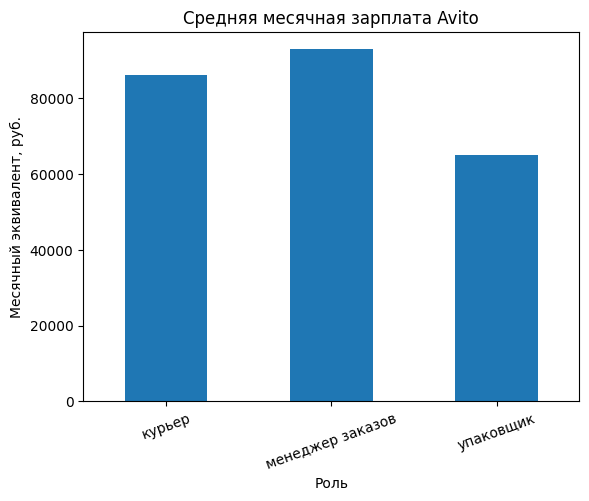

In [25]:
avito_jobs.groupby("position")["salary_monthly_estimated"].mean().round(3).plot(kind="bar")
plt.title("Средняя месячная зарплата Avito")
plt.xlabel("Роль")
plt.ylabel("Месячный эквивалент, руб.")
plt.xticks(rotation=20)
plt.show()



## Объединение данных hh.ru и Avito

Далее сравниваются:

- зарплатные ожидания соискателей из резюме hh.ru;
- предложения работодателей из вакансий Avito.

Так можно оценить, какие позиции будут наиболее дорогими для WrapItUp и какие роли можно оптимизировать или передать на аутсорс.


In [26]:
hh_packers = packers_ranked_df[["position", "salary_expected"]].copy()
hh_packers["position"] = "упаковщик"

hh_managers = managers_ranked_df[["position", "salary_expected"]].copy()
hh_managers["position"] = "менеджер заказов"

hh_couriers = couriers_df[["position", "salary_expected"]].copy()
hh_couriers["position"] = "курьер"



In [27]:
hh_final_df = pd.concat([hh_packers, hh_managers, hh_couriers], ignore_index=True)
hh_final_df



,position,salary_expected
0,упаковщик,80000
1,упаковщик,65000
2,упаковщик,90000
3,упаковщик,60000
4,упаковщик,60000
5,менеджер заказов,40000
6,менеджер заказов,40000
7,менеджер заказов,45000
8,менеджер заказов,45000
9,менеджер заказов,60000


In [28]:
hh_stats = hh_final_df.groupby("position")["salary_expected"].agg(hh_mean_salary="mean", hh_median_salary="median", hh_min_salary="min", hh_max_salary="max", hh_count="count").round(0)

hh_stats



,hh_mean_salary,hh_median_salary,hh_min_salary,hh_max_salary,hh_count
position,,,,,
курьер,60000.0,57500.0,35000,100000,10
менеджер заказов,85556.0,60000.0,40000,200000,9
упаковщик,71000.0,65000.0,60000,90000,5


In [29]:
avito_stats = avito_jobs.groupby("position")["salary_monthly_estimated"].agg(avito_mean_salary="mean", avito_median_salary="median", avito_min_salary="min", avito_max_salary="max", avito_count="count").round(0)

avito_stats



,avito_mean_salary,avito_median_salary,avito_min_salary,avito_max_salary,avito_count
position,,,,,
курьер,86100.0,90000.0,66000.0,108000.0,5
менеджер заказов,92700.0,80000.0,60000.0,150000.0,5
упаковщик,64983.0,60000.0,45000.0,110000.0,11


In [30]:
comparison_df = hh_stats.merge(avito_stats, on="position", how="inner")
comparison_df



,hh_mean_salary,hh_median_salary,hh_min_salary,hh_max_salary,hh_count,avito_mean_salary,avito_median_salary,avito_min_salary,avito_max_salary,avito_count
position,,,,,,,,,,
курьер,60000.0,57500.0,35000,100000,10,86100.0,90000.0,66000.0,108000.0,5
менеджер заказов,85556.0,60000.0,40000,200000,9,92700.0,80000.0,60000.0,150000.0,5
упаковщик,71000.0,65000.0,60000,90000,5,64983.0,60000.0,45000.0,110000.0,11


In [31]:
comparison_df["salary_gap"] = comparison_df["avito_mean_salary"] - comparison_df["hh_mean_salary"]
comparison_df



,hh_mean_salary,hh_median_salary,hh_min_salary,hh_max_salary,hh_count,avito_mean_salary,avito_median_salary,avito_min_salary,avito_max_salary,avito_count,salary_gap
position,,,,,,,,,,,
курьер,60000.0,57500.0,35000,100000,10,86100.0,90000.0,66000.0,108000.0,5,26100.0
менеджер заказов,85556.0,60000.0,40000,200000,9,92700.0,80000.0,60000.0,150000.0,5,7144.0
упаковщик,71000.0,65000.0,60000,90000,5,64983.0,60000.0,45000.0,110000.0,11,-6017.0


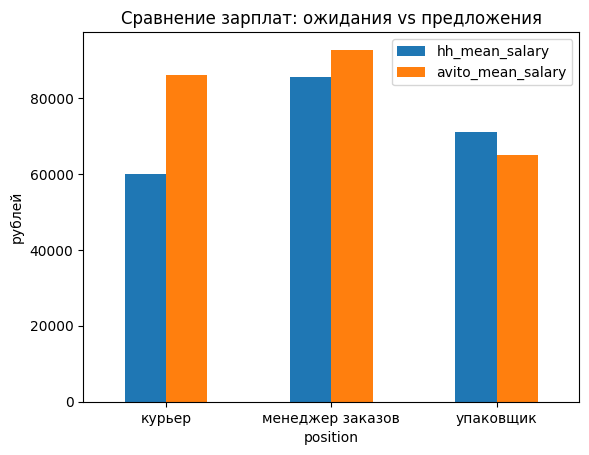

In [32]:
comparison_df[["hh_mean_salary", "avito_mean_salary"]].plot(kind="bar")

plt.title("Сравнение зарплат: ожидания vs предложения")
plt.ylabel("рублей")
plt.xticks(rotation=0)
plt.show()



In [33]:
hh_final_df["source"] = "hh.ru resumes"

avito_plot_df = avito_jobs[["position", "salary_monthly_estimated"]].copy()
avito_plot_df = avito_plot_df.rename(columns={"salary_monthly_estimated": "salary_expected"})
avito_plot_df["source"] = "avito vacancies"

plot_df = pd.concat([hh_final_df, avito_plot_df], ignore_index=True)



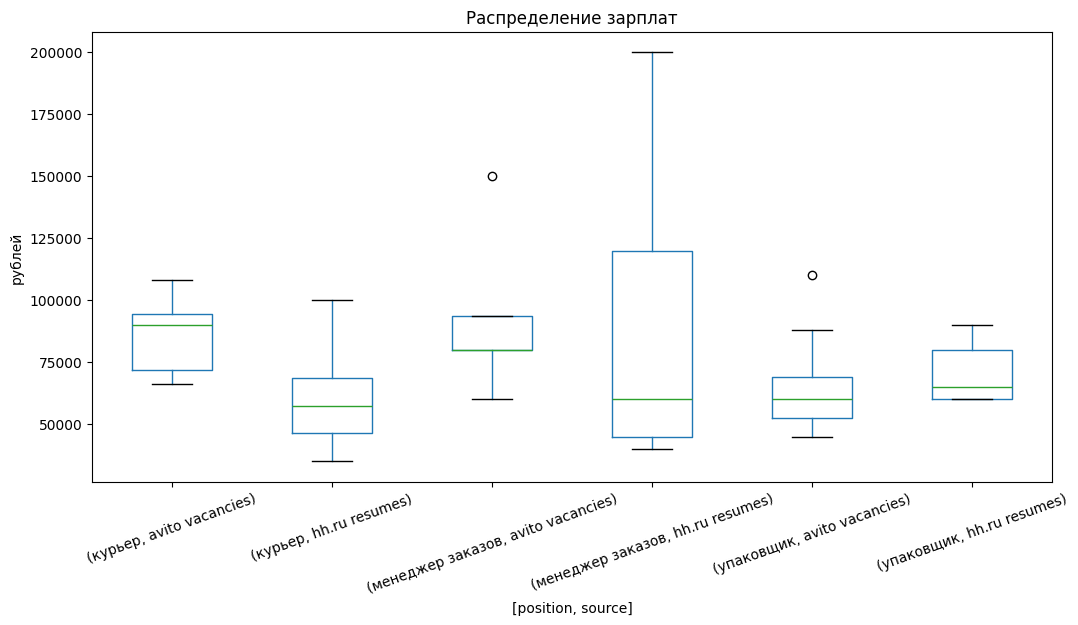

In [34]:
plot_df.boxplot(column="salary_expected", by=["position", "source"], figsize=(12, 6), grid=False)
plt.title("Распределение зарплат")
plt.suptitle("")
plt.ylabel("рублей")
plt.xticks(rotation=20)
plt.show()



### Выводы по анализу рынка труда

Было проведено сравнение зарплатных ожиданий соискателей на hh.ru и зарплат, предлагаемых работодателями на Avito.

Наиболее высокие зарплаты наблюдаются у менеджеров заказов. Это связано с необходимостью работать с клиентами, дизайнерскими наработками и тематическими интернет-ресурсами, CRM-системами и обработкой заказов.

У курьеров наблюдается заметный разброс зарплат, так как часть вакансий предполагает гибкую занятость и сдельную оплату.

Для упаковщиков и декораторов уровень зарплат оказался более стабильным. При этом именно эта категория сотрудников наиболее близка к деятельности проекта WrapItUp.

В среднем работодатели готовы предлагать зарплату выше ожиданий соискателей, что может быть связано с разбросом требований и должностных обязанностей, а также с дефицитом персонала в сфере доставки и обработки заказов.


### Допущения анализа доставки

Для оценки стоимости собственной курьерской службы была использована медианная зарплата курьера по данным hh.ru — 57 500 руб.

Дополнительно были учтены приблизительные расходы работодателя: налоги, страховые взносы и организационные расходы.


Для сравнения были использованы ориентировочные тарифы сервисов доставки:

- Ozon Delivery — 401 руб.
- CDEK — 665 руб.
- курьерские сервисы внутри Москвы — 200–1500 руб.

В качестве усреднённой стоимости городской доставки была принята величина 500 руб. за заказ.


In [45]:
courier_salary = hh_stats.loc["курьер", "hh_median_salary"]

monthly_courier_cost = courier_salary * 1.5

delivery_price = 500
orders = range(20, 501, 20)

delivery_compare_df = pd.DataFrame({
    "orders_per_month": orders,
    "own_courier_cost": [monthly_courier_cost for _ in orders],
    "outsource_cost": [n * delivery_price for n in orders]})



In [46]:
delivery_compare_df



,orders_per_month,own_courier_cost,outsource_cost
0,20,86250.0,10000
1,40,86250.0,20000
2,60,86250.0,30000
3,80,86250.0,40000
4,100,86250.0,50000
5,120,86250.0,60000
6,140,86250.0,70000
7,160,86250.0,80000
8,180,86250.0,90000
9,200,86250.0,100000


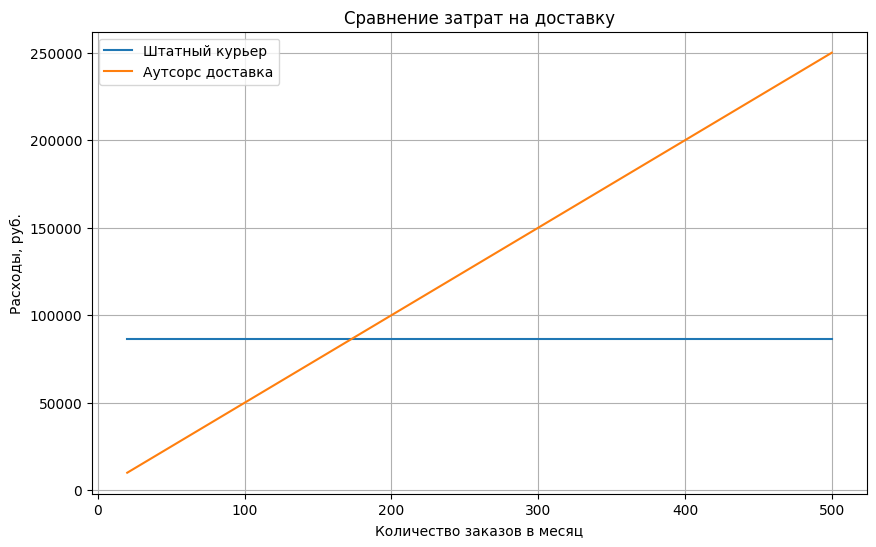

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(delivery_compare_df["orders_per_month"], delivery_compare_df["own_courier_cost"], label="Штатный курьер")
plt.plot(delivery_compare_df["orders_per_month"], delivery_compare_df["outsource_cost"], label="Аутсорс доставка")
plt.xlabel("Количество заказов в месяц")
plt.ylabel("Расходы, руб.")
plt.title("Сравнение затрат на доставку")
plt.legend()
plt.grid()
plt.show()



In [48]:
break_even_orders = monthly_courier_cost / delivery_price
break_even_orders



np.float64(172.5)

### Выводы по модели доставки

При небольшом количестве заказов использование внешних сервисов доставки является более выгодным решением, так как компания избегает постоянных расходов на содержание штатного курьера.

Однако при росте количества заказов расходы на аутсорс начинают линейно увеличиваться.

Согласно построенной модели, точка безразличия находится примерно на уровне 170–180 заказов в месяц. В выбранном сценарии предполагается около 300 заказов в месяц, поэтому содержание собственного курьера становится наиболее оправданным, с учетом того, что крьер выполняет еще и собственные задачи компании, не связанные с непосредственно доставкой клиентам.


In [51]:
packer_net = hh_stats.loc["упаковщик", "hh_median_salary"]
manager_net = hh_stats.loc["менеджер заказов", "hh_median_salary"]
courier_net = hh_stats.loc["курьер", "hh_median_salary"]

total_net_salary = packer_net + manager_net + courier_net

total_net_salary = int(total_net_salary)

total_net_salary

182500

In [52]:
ndfl_rate = 0.13
insurance_rate = 0.302

total_gross_salary = total_net_salary / (1 - ndfl_rate)
total_employer_cost = total_gross_salary * (1 + insurance_rate)

total_gross_salary, total_employer_cost



(209770.11494252874, 273120.6896551724)

In [53]:
orders_per_month = 300

staff_cost_per_order = total_employer_cost / orders_per_month
staff_cost_per_order



910.4022988505747

В стоимость одной услуги нужно закладывать примерно 910 руб. на персонал с учётом налогов и страховых взносов.
